
# DVFM2 Oracle-Z Gaussian Results

Dedicated analysis notebook for:

```text
results/synthetic_oracle_z_dvfm2
```

This experiment compares:

- `true_dgp`
- `no_latent`
- `inferred_dvfm_d1`
- `dvfm2_d1`
- `oracle_z`

The DVFM2 model uses:

- scalar shared latent `z_s`
- scalar event-private latent `z_e`
- scalar censor-private latent `z_c`

The main mechanistic question is whether DVFM2 routes the true shared Gaussian frailty into **`z_s`**, while keeping the private latents relatively uninformed.

The most important diagnostics are therefore:

1. Oracle IBS / C-index;
2. learned conditional Kendall's $\tau$;
3. original DVFM latent recovery;
4. DVFM2 shared vs private latent recovery;
5. DVFM2 shared/private KL trajectories;
6. prior vs aggregate-posterior prediction;
7. training stability and final-vs-best validation epoch.


In [1]:

from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import yaml
except ImportError:
    yaml = None

pd.set_option("display.max_columns", 250)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)

RESULT_DIR = Path("../results/synthetic_oracle_z_dvfm2")

print("Result directory:", RESULT_DIR.resolve())
if not RESULT_DIR.exists():
    raise FileNotFoundError(
        f"{RESULT_DIR} does not exist. "
        "Run this notebook from the repository root or change RESULT_DIR."
    )


Result directory: /home/thecml/dvfm-survival/results/synthetic_oracle_z_dvfm2


## 1. Load experiment outputs

In [2]:

def load_csv(path):
    path = Path(path)
    if not path.exists():
        print(f"[missing] {path}")
        return pd.DataFrame()
    df = pd.read_csv(path)
    print(f"[loaded]  {path}  shape={df.shape}")
    return df

results = load_csv(RESULT_DIR / "results_raw.csv")
results_mean_file = load_csv(RESULT_DIR / "results_mean.csv")
results_std_file = load_csv(RESULT_DIR / "results_std.csv")
profiles = load_csv(RESULT_DIR / "latent_effect_profiles.csv")

if results.empty:
    raise RuntimeError("results_raw.csv is missing or empty.")

calibration = {}
calibration_path = RESULT_DIR / "dgp_calibration.json"
if calibration_path.exists():
    calibration = json.loads(calibration_path.read_text())
    print("\nDGP calibration")
    display(pd.Series(calibration, name="value").to_frame())

config = {}
config_path = RESULT_DIR / "resolved_config.yaml"
if config_path.exists() and yaml is not None:
    config = yaml.safe_load(config_path.read_text())
    print("\nResolved config loaded.")

print("\nArchitectures:")
print(sorted(results["architecture"].dropna().astype(str).unique()))

print("\nPrediction distributions:")
print(sorted(results["prediction_distribution"].dropna().astype(str).unique()))

display(results.head())


[loaded]  ../results/synthetic_oracle_z_dvfm2/results_raw.csv  shape=(24, 116)
[loaded]  ../results/synthetic_oracle_z_dvfm2/results_mean.csv  shape=(8, 114)
[loaded]  ../results/synthetic_oracle_z_dvfm2/results_std.csv  shape=(8, 114)
[loaded]  ../results/synthetic_oracle_z_dvfm2/latent_effect_profiles.csv  shape=(42, 9)

DGP calibration


,value
target_tau,0.500000
loading,1.905733
censor_multiplier,2.122246
calibrated_tau,0.500000



Resolved config loaded.

Architectures:
['dvfm2_d1', 'inferred_dvfm_d1', 'no_latent', 'oracle_z', 'true_dgp']

Prediction distributions:
['empirical_train_true_z', 'none', 'prior_N01', 'qagg', 'true_dgp']


,seed,architecture,prediction_distribution,latent_dim,target_tau,target_censoring,achieved_censoring,overall_time_tau,learned_conditional_tau,n_parameters,best_epoch,best_validation_loss,oracle_ibs,oracle_ci_rmst,mean_rmst,shared_dim,event_private_dim,censor_private_dim,tau_absolute_error,training_wall_seconds,best_validation_reconstruction_nll,checkpoint_selection_metric,evaluated_epoch,epochs_completed,latent_all_n,latent_all_z_pearson,latent_all_z_spearman,latent_all_z_kendall,latent_all_tanhz_pearson,latent_all_tanhz_spearman,latent_all_tanhz_kendall,latent_uncensored_n,latent_uncensored_z_pearson,latent_uncensored_z_spearman,latent_uncensored_z_kendall,latent_uncensored_tanhz_pearson,latent_uncensored_tanhz_spearman,latent_uncensored_tanhz_kendall,latent_censored_n,latent_censored_z_pearson,latent_censored_z_spearman,latent_censored_z_kendall,latent_censored_tanhz_pearson,latent_censored_tanhz_spearman,latent_censored_tanhz_kendall,best_validation_reconstruction_epoch,private_kl_multiplier,shared_latent_all_n,shared_latent_all_z_pearson,shared_latent_all_z_spearman,shared_latent_all_z_kendall,shared_latent_all_tanhz_pearson,shared_latent_all_tanhz_spearman,shared_latent_all_tanhz_kendall,shared_latent_uncensored_n,shared_latent_uncensored_z_pearson,shared_latent_uncensored_z_spearman,shared_latent_uncensored_z_kendall,shared_latent_uncensored_tanhz_pearson,shared_latent_uncensored_tanhz_spearman,shared_latent_uncensored_tanhz_kendall,shared_latent_censored_n,shared_latent_censored_z_pearson,shared_latent_censored_z_spearman,shared_latent_censored_z_kendall,shared_latent_censored_tanhz_pearson,shared_latent_censored_tanhz_spearman,shared_latent_censored_tanhz_kendall,event_private_latent_all_n,event_private_latent_all_z_pearson,event_private_latent_all_z_spearman,event_private_latent_all_z_kendall,event_private_latent_all_tanhz_pearson,event_private_latent_all_tanhz_spearman,event_private_latent_all_tanhz_kendall,event_private_latent_uncensored_n,event_private_latent_uncensored_z_pearson,event_private_latent_uncensored_z_spearman,event_private_latent_uncensored_z_kendall,event_private_latent_uncensored_tanhz_pearson,event_private_latent_uncensored_tanhz_spearman,event_private_latent_uncensored_tanhz_kendall,event_private_latent_censored_n,event_private_latent_censored_z_pearson,event_private_latent_censored_z_spearman,event_private_latent_censored_z_kendall,event_private_latent_censored_tanhz_pearson,event_private_latent_censored_tanhz_spearman,event_private_latent_censored_tanhz_kendall,censor_private_latent_all_n,censor_private_latent_all_z_pearson,censor_private_latent_all_z_spearman,censor_private_latent_all_z_kendall,censor_private_latent_all_tanhz_pearson,censor_private_latent_all_tanhz_spearman,censor_private_latent_all_tanhz_kendall,censor_private_latent_uncensored_n,censor_private_latent_uncensored_z_pearson,censor_private_latent_uncensored_z_spearman,censor_private_latent_uncensored_z_kendall,censor_private_latent_uncensored_tanhz_pearson,censor_private_latent_uncensored_tanhz_spearman,censor_private_latent_uncensored_tanhz_kendall,censor_private_latent_censored_n,censor_private_latent_censored_z_pearson,censor_private_latent_censored_z_spearman,censor_private_latent_censored_z_kendall,censor_private_latent_censored_tanhz_pearson,censor_private_latent_censored_tanhz_spearman,censor_private_latent_censored_tanhz_kendall,shared_posterior_mu_mean,shared_posterior_mu_std,event_private_posterior_mu_mean,event_private_posterior_mu_std,censor_private_posterior_mu_mean,censor_private_posterior_mu_std
0,0,true_dgp,true_dgp,1,0.5,0.3,0.2975,0.462214,0.500000,0,NaN,NaN,0.117845,0.572093,0.008968,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

## 2. One row per fitted model

In [3]:

model_rows = (
    results
    .sort_values(["seed", "architecture", "prediction_distribution"])
    .drop_duplicates(["seed", "architecture"])
    .copy()
)

model_cols = [
    c for c in [
        "seed",
        "architecture",
        "latent_dim",
        "shared_dim",
        "event_private_dim",
        "censor_private_dim",
        "target_tau",
        "target_censoring",
        "achieved_censoring",
        "overall_time_tau",
        "learned_conditional_tau",
        "tau_absolute_error",
        "best_epoch",
        "evaluated_epoch",
        "epochs_completed",
        "best_validation_reconstruction_nll",
        "checkpoint_selection_metric",
        "n_parameters",
        "training_wall_seconds",
    ]
    if c in model_rows.columns
]

display(model_rows[model_cols].sort_values(["architecture", "seed"]))


,seed,architecture,latent_dim,shared_dim,event_private_dim,censor_private_dim,target_tau,target_censoring,achieved_censoring,overall_time_tau,learned_conditional_tau,tau_absolute_error,best_epoch,evaluated_epoch,epochs_completed,best_validation_reconstruction_nll,checkpoint_selection_metric,n_parameters,training_wall_seconds
4,0,dvfm2_d1,1,1.0,1.0,1.0,0.5,0.3,0.2975,0.462214,-0.003030,0.503030,10.0,200.0,200.0,-3.671562,none_final_epoch_evaluated,8308,141.410725
12,1,dvfm2_d1,1,1.0,1.0,1.0,0.5,0.3,0.2926,0.463675,-0.001978,0.501978,6.0,200.0,200.0,-3.758183,none_final_epoch_evaluated,8308,141.911307
20,2,dvfm2_d1,1,1.0,1.0,1.0,0.5,0.3,0.3003,0.459186,-0.000193,0.500193,11.0,200.0,200.0,-4.160113,none_final_epoch_evaluated,8308,140.248878
2,0,inferred_dvfm_d1,1,0.0,0.0,0.0,0.5,0.3,0.2975,0.462214,-0.217695,0.717695,10.0,200.0,200.0,-3.970699,none_final_epoch_evaluated,6118,94.965203
10,1,inferred_dvfm_d1,1,0.0,0.0,0.0,0.5,0.3,0.2926,0.463675,-0.287782,0.787782,5.0,200.0,200.0,-4.027790,none_final_epoch_evaluated,6118,95.000411
18,2,inferred_dvfm_d1,1,0.0,0.0,0.0,0.5,0.3,0.3003,0.459186,-0.260468,0.760468,6.0,200.0,200.0,-4.550872,none_final_epoch_evaluated,6118,94.298847
1,0,no_latent,0,0.0,0.0,0.0,0.5,0.3,0.2975,0.462214,0.004757,0.495243,14.0,200.0,200.0,-3.403151,none_final_epoch_evaluated,2916,62.702575
9,1,no_latent,0,0.0,0.0,0.0,0.5,0.3,0.2926,0.463675,-0.002030,0.502030,14.0,200.0,200.0,-3.505290,none_final_epoch_evaluated,2916,61.660189
17,2,no_latent,0,0.0,0.0,0.0,0.5,0.3,0.3003,0.459186,-0.001832,0.501832,14.0,200.0,200.0,-3.970946,none_final_epoch_evaluated,2916,61.057713
7,0,oracle_z,1,0.0,0.0,0.0,0.5,0.3,0.2975,0.462214,0.519585,0.019585,23.0,200.0,200.0,-4.096338,none_final_epoch_evaluated,2948,63.358416



## 3. Prediction performance

The main predictive metric is **Oracle IBS**, because the true event times are available from the simulator.

Lower is better.


,architecture,prediction_distribution,oracle_ibs_mean,oracle_ibs_std,oracle_ci_mean,oracle_ci_std,n
7,true_dgp,true_dgp,0.117281,0.007461,0.567172,0.007614,3
6,oracle_z,prior_N01,0.120114,0.009405,0.564130,0.007316,3
5,oracle_z,empirical_train_true_z,0.120226,0.009240,0.563210,0.004607,3
0,dvfm2_d1,prior_N01,0.128853,0.006656,0.553390,0.011530,3
1,dvfm2_d1,qagg,0.129049,0.006893,0.553707,0.011948,3
4,no_latent,none,0.132873,0.007232,0.550395,0.008966,3
2,inferred_dvfm_d1,prior_N01,0.158122,0.006302,0.551282,0.014860,3
3,inferred_dvfm_d1,qagg,0.160418,0.005374,0.550173,0.016477,3


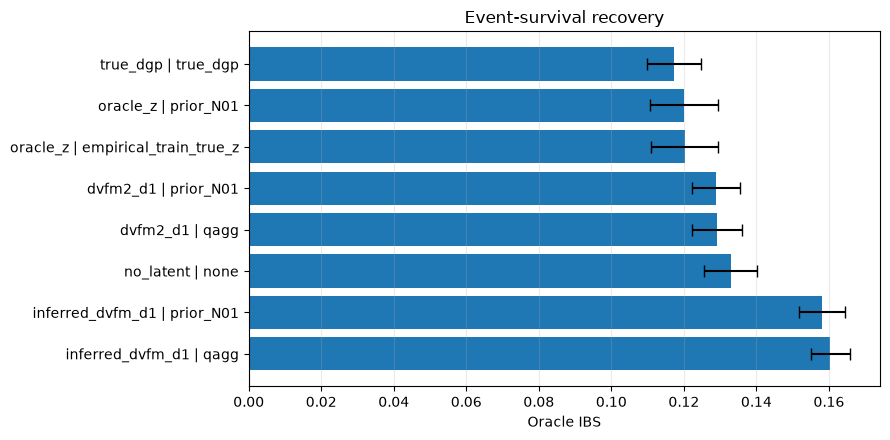

In [4]:

pred_summary = (
    results.groupby(
        ["architecture", "prediction_distribution"],
        dropna=False,
    )
    .agg(
        oracle_ibs_mean=("oracle_ibs", "mean"),
        oracle_ibs_std=("oracle_ibs", "std"),
        oracle_ci_mean=("oracle_ci_rmst", "mean"),
        oracle_ci_std=("oracle_ci_rmst", "std"),
        n=("seed", "count"),
    )
    .reset_index()
    .sort_values("oracle_ibs_mean")
)

display(pred_summary)

labels = (
    pred_summary["architecture"].astype(str)
    + " | "
    + pred_summary["prediction_distribution"].astype(str)
)

fig, ax = plt.subplots(figsize=(9, max(4.5, 0.5 * len(pred_summary))))
y = np.arange(len(pred_summary))
ax.barh(
    y,
    pred_summary["oracle_ibs_mean"],
    xerr=pred_summary["oracle_ibs_std"],
    capsize=4,
)
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("Oracle IBS")
ax.set_title("Event-survival recovery")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


## 4. Seed-level Oracle IBS

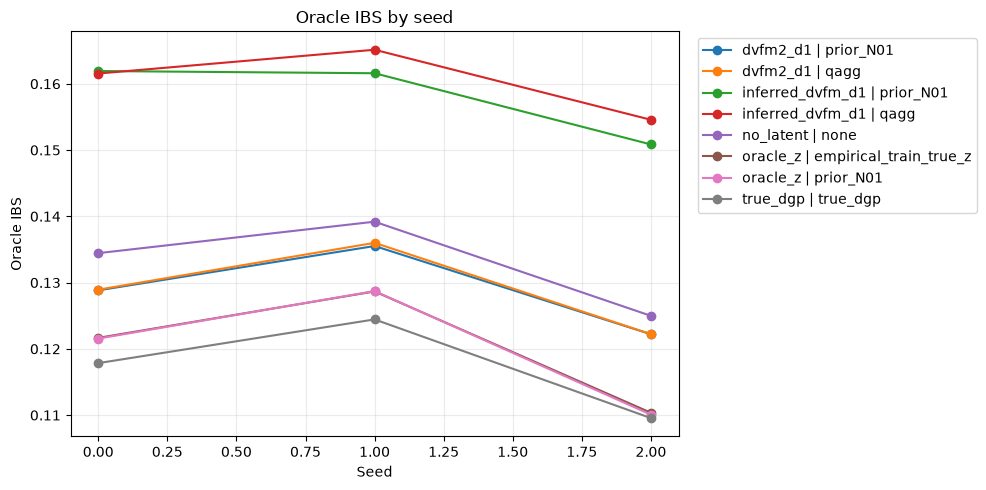

architecture             dvfm2_d1           inferred_dvfm_d1           no_latent               oracle_z            true_dgp
prediction_distribution prior_N01      qagg        prior_N01      qagg      none empirical_train_true_z prior_N01  true_dgp
seed                                                                                                                       
0                        0.128829  0.128929         0.161927  0.161548  0.134443               0.121655  0.121549  0.117845
1                        0.135521  0.136001         0.161593  0.165137  0.139191               0.128669  0.128719  0.124444
2                        0.122208  0.122217         0.150847  0.154569  0.124985               0.110356  0.110074  0.109554

In [5]:

plot_df = results.copy()
plot_df["label"] = (
    plot_df["architecture"].astype(str)
    + " | "
    + plot_df["prediction_distribution"].astype(str)
)

fig, ax = plt.subplots(figsize=(10, 5))
for label, p in plot_df.groupby("label"):
    p = p.sort_values("seed")
    ax.plot(
        p["seed"],
        p["oracle_ibs"],
        marker="o",
        label=label,
    )

ax.set_xlabel("Seed")
ax.set_ylabel("Oracle IBS")
ax.set_title("Oracle IBS by seed")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

display(
    results.pivot_table(
        index="seed",
        columns=["architecture", "prediction_distribution"],
        values="oracle_ibs",
        aggfunc="first",
    )
)



## 5. Prior vs qagg

For the original DVFM and DVFM2:

$$
\Delta_{\text{qagg-prior}}
=
IBS_{\text{qagg}} - IBS_{\text{prior}}.
$$

Negative values mean qagg is better.



inferred_dvfm_d1


prediction_distribution,seed,prior_N01,qagg,qagg_minus_prior
0,0,0.161927,0.161548,-0.000378
1,1,0.161593,0.165137,0.003544
2,2,0.150847,0.154569,0.003722


Mean qagg - prior: 0.002296013926904964 (negative = qagg better)


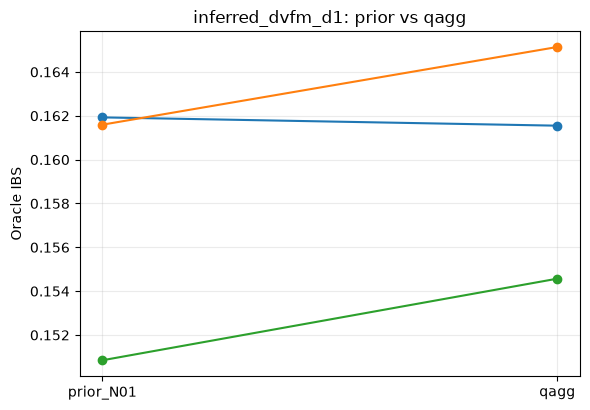


dvfm2_d1


prediction_distribution,seed,prior_N01,qagg,qagg_minus_prior
0,0,0.128829,0.128929,0.000100
1,1,0.135521,0.136001,0.000480
2,2,0.122208,0.122217,0.000009


Mean qagg - prior: 0.00019646098199439335 (negative = qagg better)


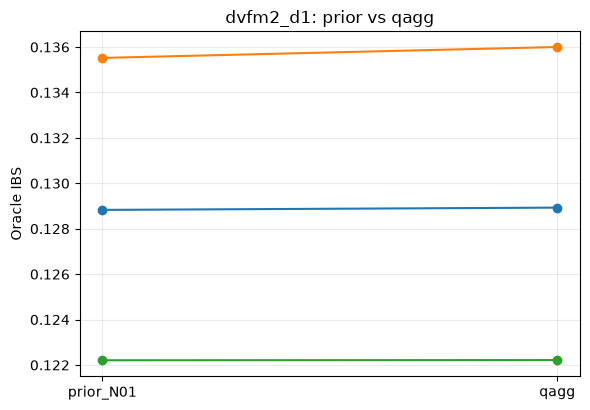

In [6]:

for architecture in ["inferred_dvfm_d1", "dvfm2_d1"]:
    p = results[results["architecture"] == architecture]

    if p.empty:
        continue

    distributions = set(p["prediction_distribution"])
    if not {"prior_N01", "qagg"}.issubset(distributions):
        print(f"{architecture}: prior/qagg pair not complete")
        continue

    paired = (
        p.pivot_table(
            index="seed",
            columns="prediction_distribution",
            values="oracle_ibs",
            aggfunc="first",
        )
        .reset_index()
    )
    paired["qagg_minus_prior"] = paired["qagg"] - paired["prior_N01"]

    print(f"\n{architecture}")
    display(paired)
    print(
        "Mean qagg - prior:",
        paired["qagg_minus_prior"].mean(),
        "(negative = qagg better)"
    )

    fig, ax = plt.subplots(figsize=(6, 4.2))
    for _, row in paired.iterrows():
        ax.plot(
            ["prior_N01", "qagg"],
            [row["prior_N01"], row["qagg"]],
            marker="o",
        )
    ax.set_ylabel("Oracle IBS")
    ax.set_title(f"{architecture}: prior vs qagg")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()



## 6. Learned conditional dependence

The current Gaussian DGP has target:

$$
\tau(T,C\mid X)=0.5.
$$

DVFM2 has the strongest structural bias toward positive shared dependence because only `z_s` can influence both margins and the current experiment constrains the two shared loadings to the same sign.


,architecture,mean,std,count
0,dvfm2_d1,-0.001733,0.001434,3
1,inferred_dvfm_d1,-0.255315,0.035326,3
2,no_latent,0.000298,0.003863,3
3,oracle_z,0.526827,0.009713,3
4,true_dgp,0.500000,0.000000,3


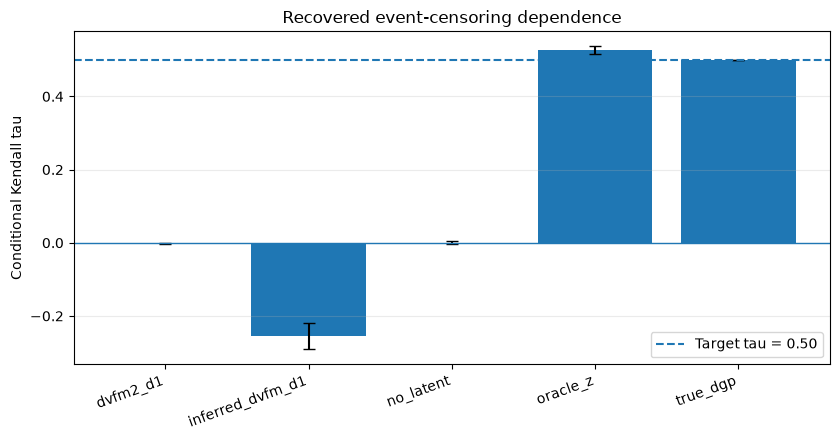

,seed,architecture,learned_conditional_tau
4,0,dvfm2_d1,-0.003030
12,1,dvfm2_d1,-0.001978
20,2,dvfm2_d1,-0.000193
2,0,inferred_dvfm_d1,-0.217695
10,1,inferred_dvfm_d1,-0.287782
18,2,inferred_dvfm_d1,-0.260468
1,0,no_latent,0.004757
9,1,no_latent,-0.002030
17,2,no_latent,-0.001832
7,0,oracle_z,0.519585


In [7]:

tau_summary = (
    model_rows.groupby("architecture")["learned_conditional_tau"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

display(tau_summary)

target_tau = (
    float(results["target_tau"].dropna().iloc[0])
    if "target_tau" in results.columns and results["target_tau"].notna().any()
    else float(calibration.get("target_tau", np.nan))
)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
x = np.arange(len(tau_summary))
ax.bar(
    x,
    tau_summary["mean"],
    yerr=tau_summary["std"],
    capsize=4,
)
ax.set_xticks(x)
ax.set_xticklabels(tau_summary["architecture"], rotation=20, ha="right")
if np.isfinite(target_tau):
    ax.axhline(target_tau, linestyle="--", label=f"Target tau = {target_tau:.2f}")
ax.axhline(0, linewidth=1)
ax.set_ylabel("Conditional Kendall tau")
ax.set_title("Recovered event-censoring dependence")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

display(
    model_rows[
        ["seed", "architecture", "learned_conditional_tau"]
    ].sort_values(["architecture", "seed"])
)


## 7. Original DVFM true-z recovery

Original DVFM recovery columns:
  latent_all_z_pearson
  latent_all_z_spearman
  latent_all_z_kendall
  latent_uncensored_z_pearson
  latent_uncensored_z_spearman
  latent_uncensored_z_kendall
  latent_censored_z_pearson
  latent_censored_z_spearman
  latent_censored_z_kendall


,metric,mean,std
0,latent_all_z_pearson,0.079408,0.033236
1,latent_all_z_spearman,0.036981,0.063838
2,latent_all_z_kendall,0.023650,0.043489
3,latent_uncensored_z_pearson,-0.105828,0.133998
4,latent_uncensored_z_spearman,-0.092876,0.118631
5,latent_uncensored_z_kendall,-0.062669,0.080461
6,latent_censored_z_pearson,-0.021259,0.041438
7,latent_censored_z_spearman,-0.002030,0.033269
8,latent_censored_z_kendall,-0.001273,0.022083


,seed,latent_all_z_spearman,latent_uncensored_z_spearman,latent_censored_z_spearman
2,0,0.064512,-0.070217,-0.036066
10,1,-0.036003,-0.221201,-0.000438
18,2,0.082434,0.012791,0.030414


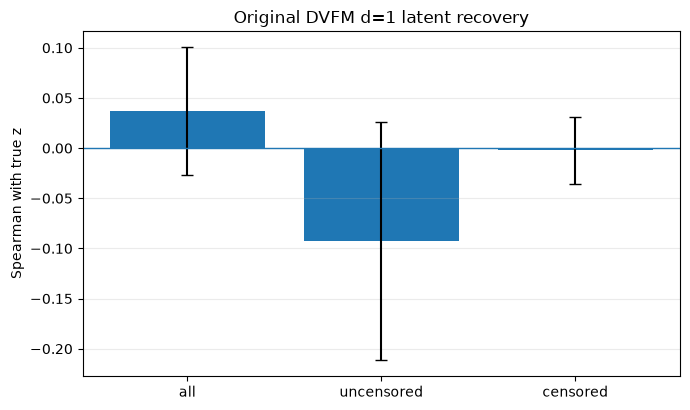

In [8]:

dvfm1 = model_rows[model_rows["architecture"] == "inferred_dvfm_d1"].copy()

dvfm1_recovery_cols = [
    c for c in dvfm1.columns
    if c.startswith("latent_")
    and "_z_" in c
    and any(m in c for m in ["pearson", "spearman", "kendall"])
]

print("Original DVFM recovery columns:")
for c in dvfm1_recovery_cols:
    print(" ", c)

if not dvfm1.empty and dvfm1_recovery_cols:
    rows = []
    for col in dvfm1_recovery_cols:
        rows.append({
            "metric": col,
            "mean": dvfm1[col].mean(),
            "std": dvfm1[col].std(),
        })
    display(pd.DataFrame(rows))

preferred = [
    "latent_all_z_spearman",
    "latent_uncensored_z_spearman",
    "latent_censored_z_spearman",
]

available = [c for c in preferred if c in dvfm1.columns]
if available:
    display(dvfm1[["seed"] + available].sort_values("seed"))

    means = [dvfm1[c].mean() for c in available]
    stds = [dvfm1[c].std() for c in available]
    labels = [
        c.replace("latent_", "").replace("_z_spearman", "")
        for c in available
    ]

    fig, ax = plt.subplots(figsize=(7, 4.2))
    ax.bar(np.arange(len(labels)), means, yerr=stds, capsize=4)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.axhline(0, linewidth=1)
    ax.set_ylabel("Spearman with true z")
    ax.set_title("Original DVFM d=1 latent recovery")
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()



## 8. DVFM2 shared vs private true-z recovery

This is the key mechanistic DVFM2 diagnostic.

The desired pattern is:

$$
\operatorname{corr}(z_s,z_{\mathrm{true}})
\gg
\operatorname{corr}(z_e,z_{\mathrm{true}})
$$

and

$$
\operatorname{corr}(z_s,z_{\mathrm{true}})
\gg
\operatorname{corr}(z_c,z_{\mathrm{true}}).
$$

Prediction improvement without this separation would be weaker evidence for the intended mechanism.


,component,subgroup,mean,std,column
0,Shared z_s,all,0.457069,0.057095,shared_latent_all_z_spearman
1,Shared z_s,uncensored,0.563516,0.116157,shared_latent_uncensored_z_spearman
2,Shared z_s,censored,0.454164,0.112601,shared_latent_censored_z_spearman
3,Event-private z_e,all,0.293309,0.062361,event_private_latent_all_z_spearman
4,Event-private z_e,uncensored,0.439090,0.104566,event_private_latent_uncensored_z_spearman
5,Event-private z_e,censored,0.280260,0.040823,event_private_latent_censored_z_spearman
6,Censor-private z_c,all,0.344312,0.043660,censor_private_latent_all_z_spearman
7,Censor-private z_c,uncensored,0.438392,0.043090,censor_private_latent_uncensored_z_spearman
8,Censor-private z_c,censored,0.316440,0.053843,censor_private_latent_censored_z_spearman


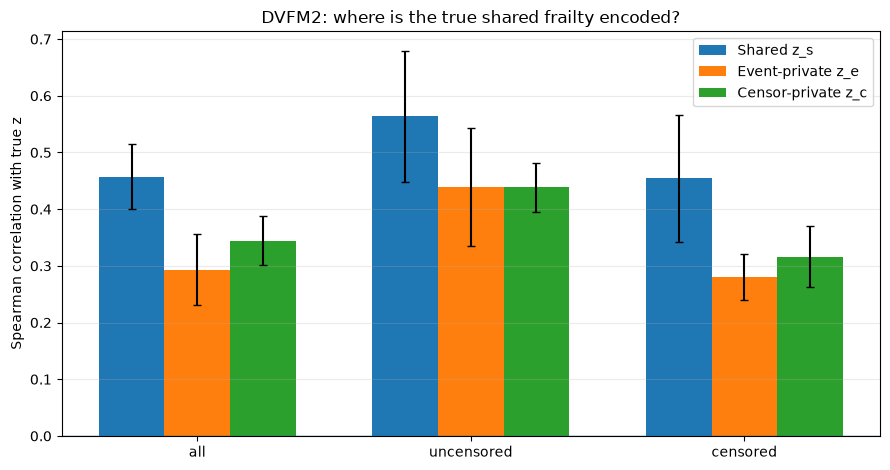

In [9]:

dvfm2 = model_rows[model_rows["architecture"] == "dvfm2_d1"].copy()

components = {
    "Shared z_s": "shared",
    "Event-private z_e": "event_private",
    "Censor-private z_c": "censor_private",
}

rows = []
for display_name, prefix in components.items():
    for subgroup in ["all", "uncensored", "censored"]:
        col = f"{prefix}_latent_{subgroup}_z_spearman"
        if col in dvfm2.columns:
            rows.append({
                "component": display_name,
                "subgroup": subgroup,
                "mean": dvfm2[col].mean(),
                "std": dvfm2[col].std(),
                "column": col,
            })

dvfm2_recovery = pd.DataFrame(rows)
display(dvfm2_recovery)

if not dvfm2_recovery.empty:
    subgroups = ["all", "uncensored", "censored"]
    component_names = list(components.keys())
    x = np.arange(len(subgroups))
    width = 0.24

    fig, ax = plt.subplots(figsize=(9, 4.8))
    for j, component in enumerate(component_names):
        p = dvfm2_recovery[
            dvfm2_recovery["component"] == component
        ].set_index("subgroup")

        means = [p.loc[s, "mean"] if s in p.index else np.nan for s in subgroups]
        stds = [p.loc[s, "std"] if s in p.index else np.nan for s in subgroups]

        ax.bar(
            x + (j - 1) * width,
            means,
            width=width,
            yerr=stds,
            capsize=3,
            label=component,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(subgroups)
    ax.set_ylabel("Spearman correlation with true z")
    ax.set_title("DVFM2: where is the true shared frailty encoded?")
    ax.axhline(0, linewidth=1)
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


### Seed-level DVFM2 recovery

,seed,shared_latent_all_z_spearman,event_private_latent_all_z_spearman,censor_private_latent_all_z_spearman
4,0,0.458038,0.232371,0.394491
12,1,0.513673,0.357002,0.323429
20,2,0.399495,0.290553,0.315015


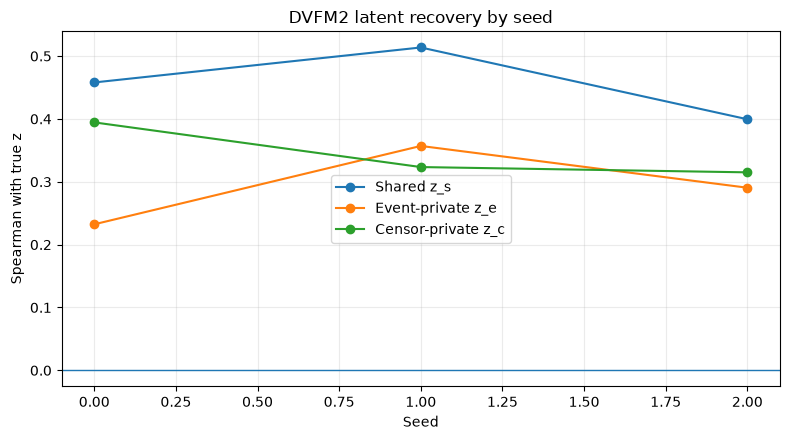

In [10]:

seed_cols = [
    "seed",
    "shared_latent_all_z_spearman",
    "event_private_latent_all_z_spearman",
    "censor_private_latent_all_z_spearman",
]
seed_cols = [c for c in seed_cols if c in dvfm2.columns]

if len(seed_cols) > 1:
    display(dvfm2[seed_cols].sort_values("seed"))

    fig, ax = plt.subplots(figsize=(8, 4.5))
    mapping = {
        "shared_latent_all_z_spearman": "Shared z_s",
        "event_private_latent_all_z_spearman": "Event-private z_e",
        "censor_private_latent_all_z_spearman": "Censor-private z_c",
    }
    for col, label in mapping.items():
        if col in dvfm2.columns:
            p = dvfm2.sort_values("seed")
            ax.plot(p["seed"], p[col], marker="o", label=label)

    ax.set_xlabel("Seed")
    ax.set_ylabel("Spearman with true z")
    ax.set_title("DVFM2 latent recovery by seed")
    ax.axhline(0, linewidth=1)
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()



## 9. DVFM2 posterior activation

These are deployment-available diagnostics and do not use the true synthetic latent.

Large posterior-mean variation indicates that a latent branch is actively encoding subject-level information. A nearly collapsed branch should have little variation in posterior means.


,seed,shared_posterior_mu_mean,shared_posterior_mu_std,event_private_posterior_mu_mean,event_private_posterior_mu_std,censor_private_posterior_mu_mean,censor_private_posterior_mu_std
4,0,0.001752,0.285673,-7.155218e-07,0.004821,-0.000236,0.073233
12,1,0.001730,0.161428,-4.791070e-05,0.006064,0.000071,0.095393
20,2,-0.000033,0.002670,1.920637e-04,0.011380,0.000430,0.060695


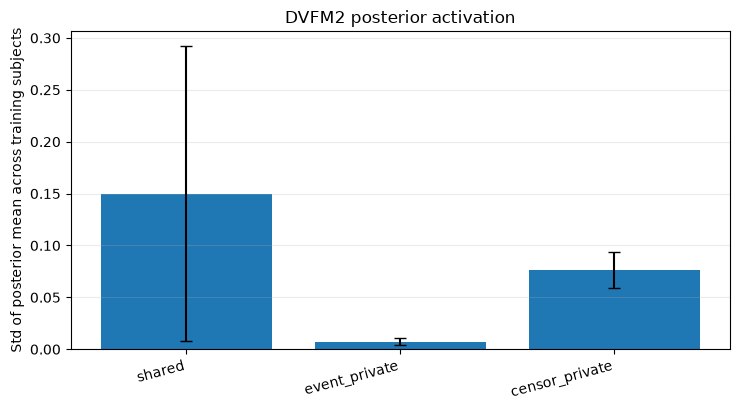

In [11]:

posterior_cols = [
    c for c in [
        "shared_posterior_mu_mean",
        "shared_posterior_mu_std",
        "event_private_posterior_mu_mean",
        "event_private_posterior_mu_std",
        "censor_private_posterior_mu_mean",
        "censor_private_posterior_mu_std",
    ]
    if c in dvfm2.columns
]

if posterior_cols:
    display(dvfm2[["seed"] + posterior_cols].sort_values("seed"))

    std_cols = [
        c for c in posterior_cols
        if c.endswith("_posterior_mu_std")
    ]
    labels = [
        c.replace("_posterior_mu_std", "")
        for c in std_cols
    ]
    means = [dvfm2[c].mean() for c in std_cols]
    stds = [dvfm2[c].std() for c in std_cols]

    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    ax.bar(np.arange(len(labels)), means, yerr=stds, capsize=4)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=15, ha="right")
    ax.set_ylabel("Std of posterior mean across training subjects")
    ax.set_title("DVFM2 posterior activation")
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


## 10. Training histories

In [12]:

HISTORY_DIR = RESULT_DIR / "training_history"
history_files = sorted(HISTORY_DIR.glob("*.csv")) if HISTORY_DIR.exists() else []

print(f"Found {len(history_files)} history files")

histories = []
for path in history_files:
    h = pd.read_csv(path)

    m = re.match(r"seed(\d+)_(.+)", path.stem)
    seed = int(m.group(1)) if m else None
    architecture = m.group(2) if m else path.stem

    h["seed"] = seed
    h["architecture"] = architecture
    histories.append(h)

history = pd.concat(histories, ignore_index=True) if histories else pd.DataFrame()
display(history.head() if not history.empty else history)


Found 12 history files


,epoch,beta_shared,beta_private,learning_rate,train_loss,train_reconstruction_nll,train_kl_shared,train_kl_event_private,train_kl_censor_private,train_kl_private_total,train_kl_total,validation_loss,validation_reconstruction_nll,validation_kl_shared,validation_kl_event_private,validation_kl_censor_private,validation_kl_private_total,validation_kl_total,shared_loading_event,shared_loading_censor,event_private_loading,censor_private_loading,seed,architecture,beta,train_kl,validation_kl
0,1,0.02,0.04,0.001,-2.812325,-2.881732,3.129389,0.117281,0.053201,0.170482,3.299871,-3.298119,-3.342147,2.009129,0.036686,0.059461,0.096147,2.105276,0.545217,0.519593,0.316352,0.315234,0,dvfm2_d1,NaN,NaN,NaN
1,2,0.04,0.08,0.001,-3.344588,-3.374979,0.448377,0.041791,0.113905,0.155697,0.604074,-3.407457,-3.448827,0.189792,0.089679,0.332551,0.422230,0.612023,0.544581,0.511551,0.345953,0.446073,0,dvfm2_d1,NaN,NaN,NaN
2,3,0.06,0.12,0.001,-3.431076,-3.505762,0.155264,0.100518,0.444229,0.544747,0.700012,-3.465642,-3.561180,0.140615,0.123012,0.602837,0.725849,0.866464,0.538499,0.496096,0.408314,0.618593,0,dvfm2_d1,NaN,NaN,NaN
3,4,0.08,0.16,0.001,-3.465822,-3.576463,0.117259,0.079831,0.553045,0.632876,0.750134,-3.507819,-3.635971,0.129151,0.067684,0.668694,0.736378,0.865529,0.535605,0.469112,0.419431,0.744832,0,dvfm2_d1,NaN,NaN,NaN
4,5,0.10,0.20,0.001,-3.505073,-3.632379,0.104203,0.046794,0.537635,0.584429,0.688633,-3.513445,-3.647846,0.121468,0.054921,0.556347,0.611268,0.732736,0.531058,0.445529,0.410963,0.842427,0,dvfm2_d1,NaN,NaN,NaN


### Validation reconstruction NLL

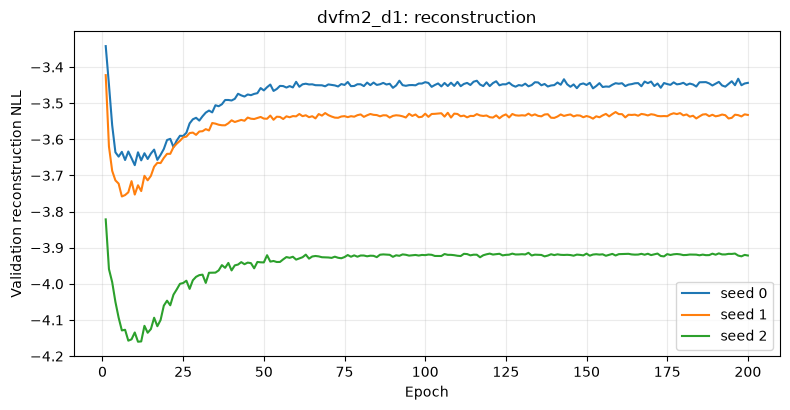

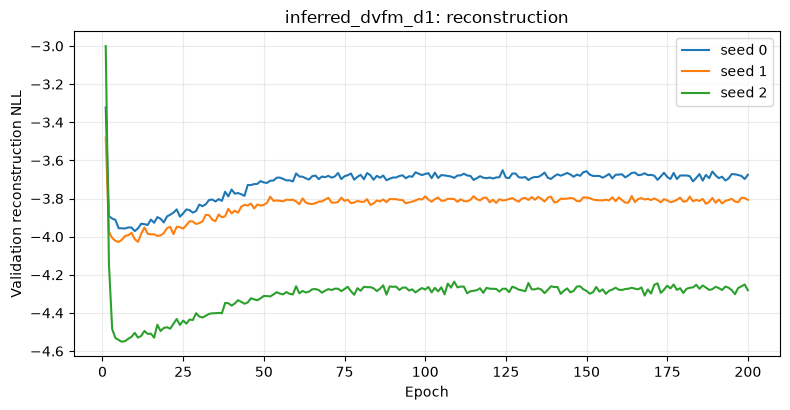

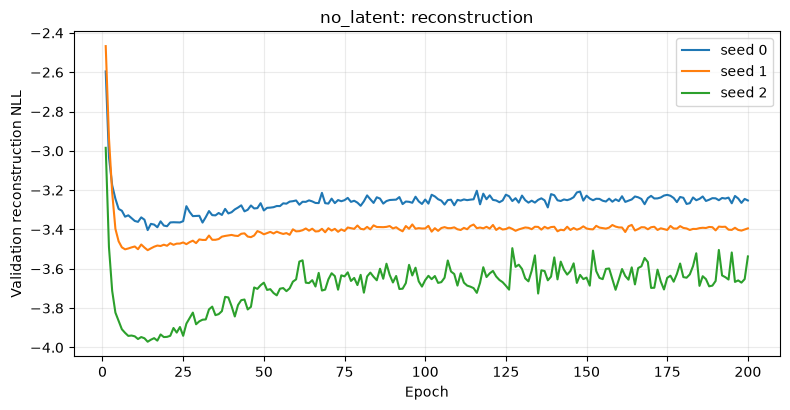

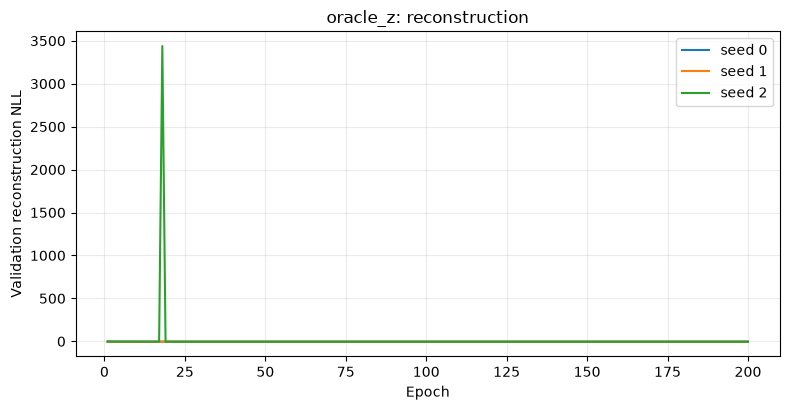

In [13]:

if not history.empty:
    for architecture in sorted(history["architecture"].unique()):
        p = history[history["architecture"] == architecture]

        recon_col = (
            "validation_reconstruction_nll"
            if "validation_reconstruction_nll" in p.columns
            else None
        )
        if recon_col is None:
            continue

        fig, ax = plt.subplots(figsize=(8, 4.2))
        for seed, s in p.groupby("seed"):
            ax.plot(
                s["epoch"],
                s[recon_col],
                label=f"seed {seed}",
            )

        ax.set_xlabel("Epoch")
        ax.set_ylabel("Validation reconstruction NLL")
        ax.set_title(f"{architecture}: reconstruction")
        ax.legend()
        ax.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()



## 11. DVFM2 KL allocation through training

This is one of the most important DVFM2-specific plots.

For the current pure shared-frailty DGP, the desirable qualitative behavior is:

$$
KL_S > 0,
$$

while ideally

$$
KL_E \approx 0,
\qquad
KL_C \approx 0.
$$


Available DVFM2 KL columns: ['validation_kl_shared', 'validation_kl_event_private', 'validation_kl_censor_private', 'validation_kl_private_total', 'validation_kl_total']


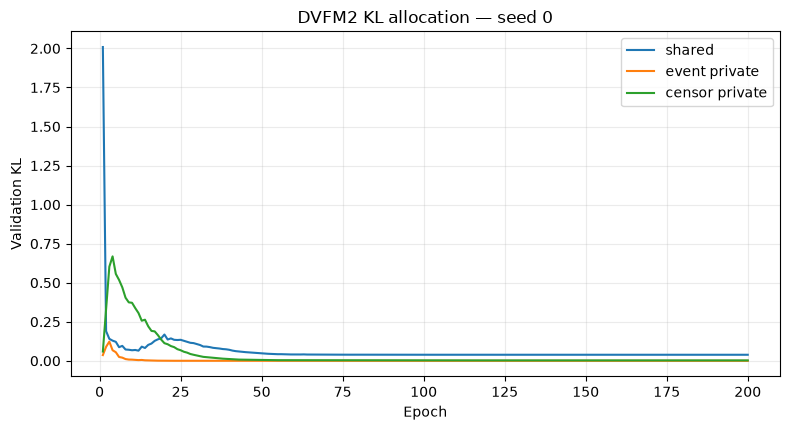

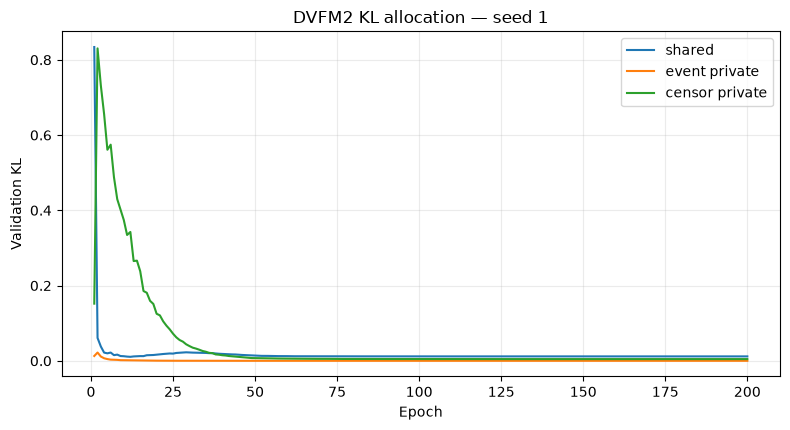

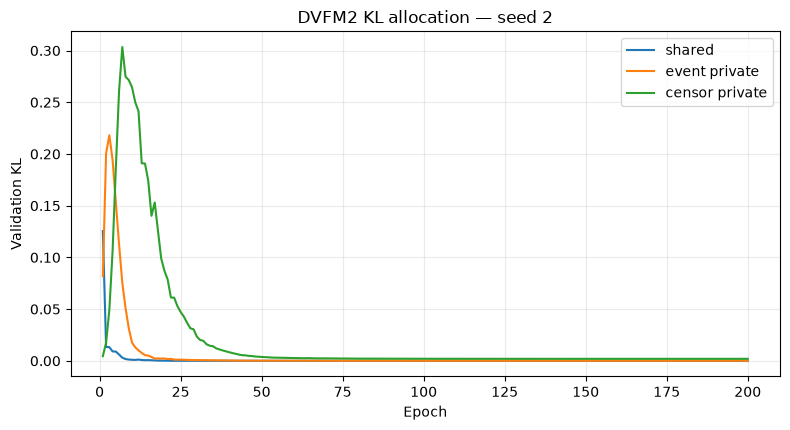

In [14]:

dvfm2_hist = history[history["architecture"] == "dvfm2_d1"].copy()

kl_cols = [
    c for c in [
        "validation_kl_shared",
        "validation_kl_event_private",
        "validation_kl_censor_private",
        "validation_kl_private_total",
        "validation_kl_total",
    ]
    if c in dvfm2_hist.columns
]

print("Available DVFM2 KL columns:", kl_cols)

if not dvfm2_hist.empty:
    main_kl_cols = [
        c for c in [
            "validation_kl_shared",
            "validation_kl_event_private",
            "validation_kl_censor_private",
        ]
        if c in dvfm2_hist.columns
    ]

    for seed, s in dvfm2_hist.groupby("seed"):
        fig, ax = plt.subplots(figsize=(8, 4.4))
        for col in main_kl_cols:
            label = (
                col.replace("validation_kl_", "")
                .replace("_private", " private")
            )
            ax.plot(s["epoch"], s[col], label=label)

        ax.set_xlabel("Epoch")
        ax.set_ylabel("Validation KL")
        ax.set_title(f"DVFM2 KL allocation — seed {seed}")
        ax.legend()
        ax.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()


### Mean KL trajectory across seeds

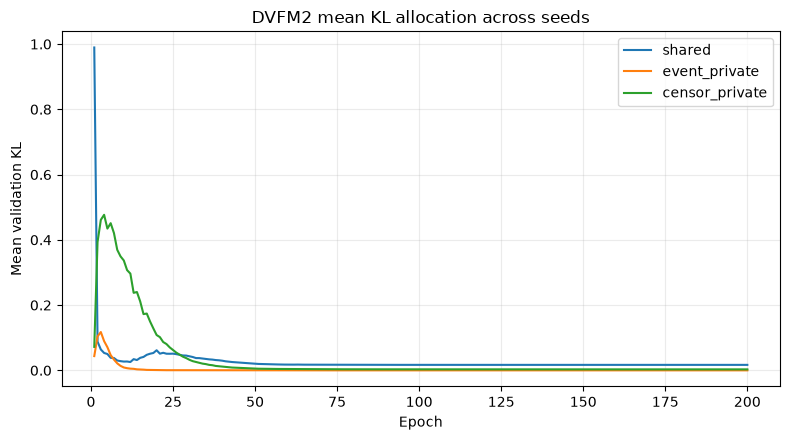

In [15]:

if not dvfm2_hist.empty:
    main_kl_cols = [
        c for c in [
            "validation_kl_shared",
            "validation_kl_event_private",
            "validation_kl_censor_private",
        ]
        if c in dvfm2_hist.columns
    ]

    if main_kl_cols:
        mean_hist = dvfm2_hist.groupby("epoch")[main_kl_cols].mean()

        fig, ax = plt.subplots(figsize=(8, 4.5))
        for col in main_kl_cols:
            ax.plot(
                mean_hist.index,
                mean_hist[col],
                label=col.replace("validation_kl_", ""),
            )

        ax.set_xlabel("Epoch")
        ax.set_ylabel("Mean validation KL")
        ax.set_title("DVFM2 mean KL allocation across seeds")
        ax.legend()
        ax.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()


## 12. DVFM2 latent loadings through training

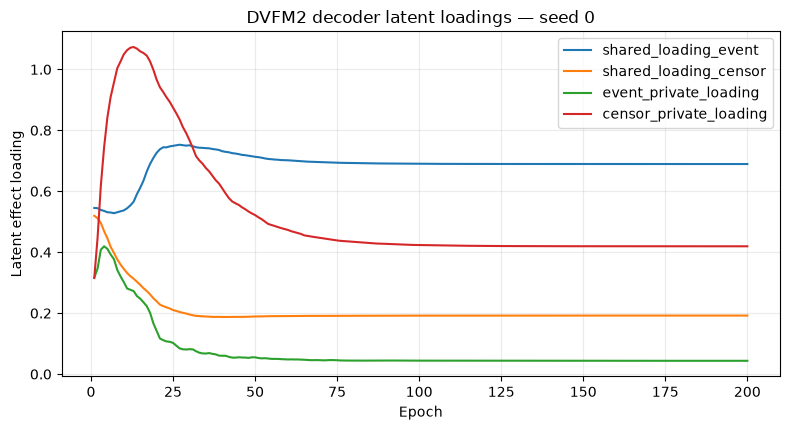

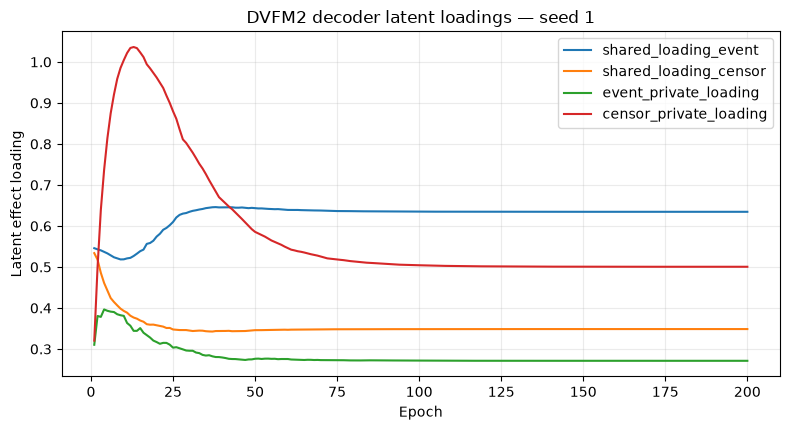

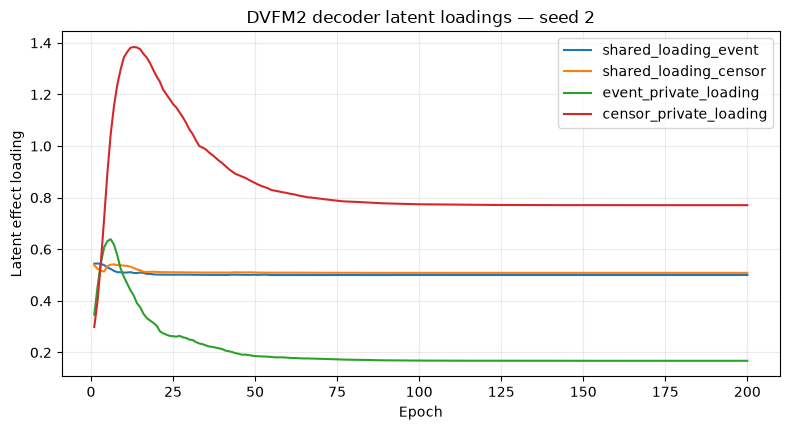

In [16]:

loading_cols = [
    c for c in [
        "shared_loading_event",
        "shared_loading_censor",
        "event_private_loading",
        "censor_private_loading",
    ]
    if c in dvfm2_hist.columns
]

if not dvfm2_hist.empty and loading_cols:
    for seed, s in dvfm2_hist.groupby("seed"):
        fig, ax = plt.subplots(figsize=(8, 4.4))
        for col in loading_cols:
            ax.plot(s["epoch"], s[col], label=col)

        ax.set_xlabel("Epoch")
        ax.set_ylabel("Latent effect loading")
        ax.set_title(f"DVFM2 decoder latent loadings — seed {seed}")
        ax.legend()
        ax.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()


## 13. Best validation epoch vs final evaluated epoch

,seed,architecture,best_epoch,evaluated_epoch,epochs_completed,best_validation_reconstruction_nll,checkpoint_selection_metric
4,0,dvfm2_d1,10.0,200.0,200.0,-3.671562,none_final_epoch_evaluated
12,1,dvfm2_d1,6.0,200.0,200.0,-3.758183,none_final_epoch_evaluated
20,2,dvfm2_d1,11.0,200.0,200.0,-4.160113,none_final_epoch_evaluated
2,0,inferred_dvfm_d1,10.0,200.0,200.0,-3.970699,none_final_epoch_evaluated
10,1,inferred_dvfm_d1,5.0,200.0,200.0,-4.027790,none_final_epoch_evaluated
18,2,inferred_dvfm_d1,6.0,200.0,200.0,-4.550872,none_final_epoch_evaluated
1,0,no_latent,14.0,200.0,200.0,-3.403151,none_final_epoch_evaluated
9,1,no_latent,14.0,200.0,200.0,-3.505290,none_final_epoch_evaluated
17,2,no_latent,14.0,200.0,200.0,-3.970946,none_final_epoch_evaluated
7,0,oracle_z,23.0,200.0,200.0,-4.096338,none_final_epoch_evaluated


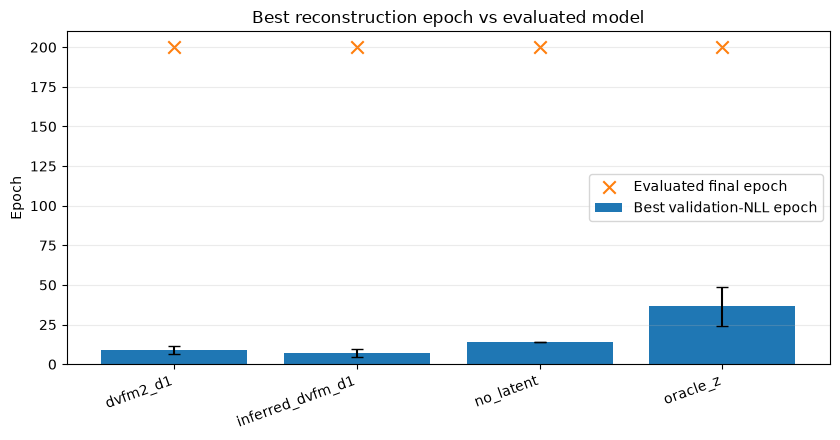

In [17]:

trained = model_rows[model_rows["architecture"] != "true_dgp"].copy()

cols = [
    c for c in [
        "seed",
        "architecture",
        "best_epoch",
        "evaluated_epoch",
        "epochs_completed",
        "best_validation_reconstruction_nll",
        "checkpoint_selection_metric",
    ]
    if c in trained.columns
]
display(trained[cols].sort_values(["architecture", "seed"]))

if {"best_epoch", "evaluated_epoch"}.issubset(trained.columns):
    agg = (
        trained.groupby("architecture")
        .agg(
            best_epoch_mean=("best_epoch", "mean"),
            best_epoch_std=("best_epoch", "std"),
            evaluated_epoch_mean=("evaluated_epoch", "mean"),
        )
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(8.5, 4.5))
    x = np.arange(len(agg))
    ax.bar(
        x,
        agg["best_epoch_mean"],
        yerr=agg["best_epoch_std"],
        capsize=4,
        label="Best validation-NLL epoch",
    )
    ax.scatter(
        x,
        agg["evaluated_epoch_mean"],
        marker="x",
        s=80,
        label="Evaluated final epoch",
    )
    ax.set_xticks(x)
    ax.set_xticklabels(agg["architecture"], rotation=20, ha="right")
    ax.set_ylabel("Epoch")
    ax.set_title("Best reconstruction epoch vs evaluated model")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


## 14. Original DVFM / Oracle latent-effect profiles

,seed,architecture,z,event_shape,event_scale,event_mean,censor_shape,censor_scale,censor_mean
0,0,inferred_dvfm_d1,-3.0,0.335886,33.225735,193.740256,0.476335,0.008387,0.018421
1,0,inferred_dvfm_d1,-2.0,0.448588,12.941590,32.303984,0.563466,0.007040,0.011557
2,0,inferred_dvfm_d1,-1.0,0.546804,0.054531,0.093678,0.626673,0.010038,0.014305
3,0,inferred_dvfm_d1,0.0,0.595200,0.009076,0.013800,0.485134,0.704276,1.491602
4,0,inferred_dvfm_d1,1.0,0.619935,0.007086,0.010231,0.852926,4.436959,4.816907


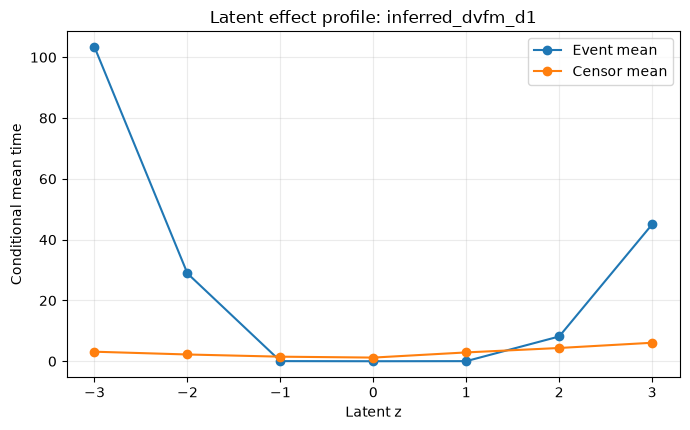

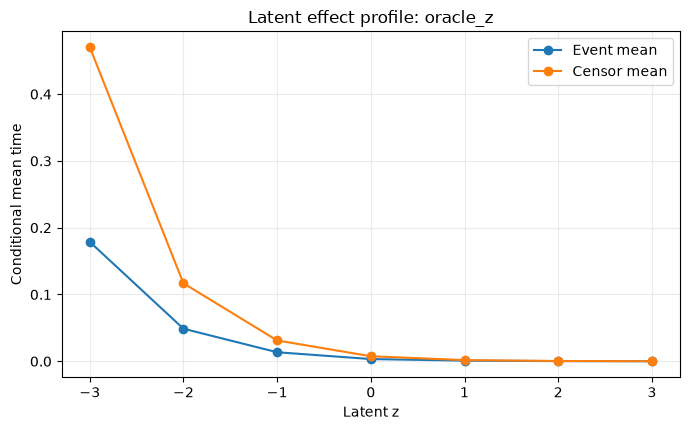


DVFM2 is intentionally not in latent_effect_profiles.csv because it has separate z_s, z_e, and z_c paths.


In [18]:

if profiles.empty:
    print("No latent_effect_profiles.csv found.")
else:
    display(profiles.head())

    if {"architecture", "z", "event_mean", "censor_mean"}.issubset(profiles.columns):
        for architecture in sorted(profiles["architecture"].dropna().unique()):
            p = (
                profiles[profiles["architecture"] == architecture]
                .groupby("z", as_index=False)
                .agg(
                    event_mean=("event_mean", "mean"),
                    censor_mean=("censor_mean", "mean"),
                )
                .sort_values("z")
            )

            fig, ax = plt.subplots(figsize=(7, 4.4))
            ax.plot(p["z"], p["event_mean"], marker="o", label="Event mean")
            ax.plot(p["z"], p["censor_mean"], marker="o", label="Censor mean")
            ax.set_xlabel("Latent z")
            ax.set_ylabel("Conditional mean time")
            ax.set_title(f"Latent effect profile: {architecture}")
            ax.legend()
            ax.grid(alpha=0.25)
            plt.tight_layout()
            plt.show()

print(
    "\nDVFM2 is intentionally not in latent_effect_profiles.csv because "
    "it has separate z_s, z_e, and z_c paths."
)



## 15. Compact mechanistic comparison

This table is intended to answer the core question quickly:

> Did DVFM2 improve prediction **and** move the true shared frailty into the explicitly shared latent?


In [19]:

rows = []

for architecture in sorted(results["architecture"].unique()):
    p = results[results["architecture"] == architecture]

    for pred_dist in sorted(p["prediction_distribution"].astype(str).unique()):
        pp = p[p["prediction_distribution"].astype(str) == pred_dist]
        if pp.empty:
            continue

        row = {
            "architecture": architecture,
            "prediction_distribution": pred_dist,
            "oracle_ibs": pp["oracle_ibs"].mean(),
            "oracle_ci_rmst": pp["oracle_ci_rmst"].mean(),
        }

        m = model_rows[model_rows["architecture"] == architecture]
        if not m.empty:
            row["learned_tau"] = m["learned_conditional_tau"].mean()

            for col in [
                "latent_all_z_spearman",
                "shared_latent_all_z_spearman",
                "event_private_latent_all_z_spearman",
                "censor_private_latent_all_z_spearman",
            ]:
                if col in m.columns:
                    row[col] = m[col].mean()

        rows.append(row)

compact = pd.DataFrame(rows).sort_values("oracle_ibs")
display(compact)


,architecture,prediction_distribution,oracle_ibs,oracle_ci_rmst,learned_tau,latent_all_z_spearman,shared_latent_all_z_spearman,event_private_latent_all_z_spearman,censor_private_latent_all_z_spearman
7,true_dgp,true_dgp,0.117281,0.567172,0.500000,NaN,NaN,NaN,NaN
6,oracle_z,prior_N01,0.120114,0.564130,0.526827,NaN,NaN,NaN,NaN
5,oracle_z,empirical_train_true_z,0.120226,0.563210,0.526827,NaN,NaN,NaN,NaN
0,dvfm2_d1,prior_N01,0.128853,0.553390,-0.001733,NaN,0.457069,0.293309,0.344312
1,dvfm2_d1,qagg,0.129049,0.553707,-0.001733,NaN,0.457069,0.293309,0.344312
4,no_latent,none,0.132873,0.550395,0.000298,NaN,NaN,NaN,NaN
2,inferred_dvfm_d1,prior_N01,0.158122,0.551282,-0.255315,0.036981,NaN,NaN,NaN
3,inferred_dvfm_d1,qagg,0.160418,0.550173,-0.255315,0.036981,NaN,NaN,NaN



## 16. Interpretation guide

### Strong DVFM2 success

The strongest result would combine:

- lower Oracle IBS than original `inferred_dvfm_d1`;
- learned Kendall's $\tau$ near the true value;
- high `shared_latent_all_z_spearman`;
- substantially lower true-$z$ recovery in `event_private` and `censor_private`;
- active shared KL;
- relatively weak private KLs.

### Prediction improves but shared recovery remains poor

Then the architectural restriction helps event-distribution estimation, but there is still little evidence that the model has identified the intended frailty.

### Private latents recover true z as strongly as z_s

Then the decomposition is not working as intended. The private branches are duplicating the shared information despite their higher KL cost.

### z_s recovers true z but prediction remains poor

Then latent inference is likely working, but the generative event marginal / prediction marginalization still needs attention.

### Learned tau is correct but true-z recovery is poor

Then DVFM2 has recovered an observationally equivalent dependence mechanism rather than the actual subject-level frailty.

This distinction is important: recovering the dependence distribution is weaker than recovering the true latent variable itself.
